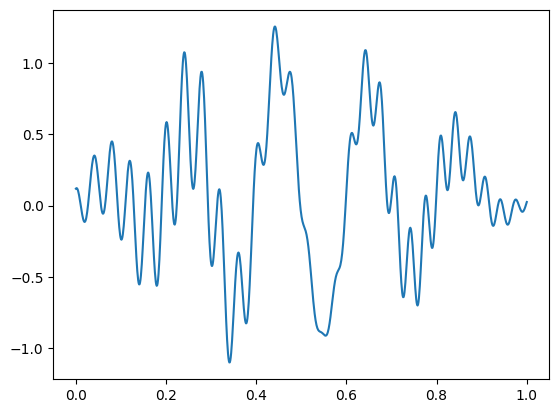

In [1]:
import torch
import matplotlib.pyplot as plt
import scipy
from time import time

def test_function(x):
    term1 = torch.sin( 10* torch.pi * x) * torch.exp(-10 * (x - 0.5)**2)
    term2 = 0.5 * torch.cos(50 * torch.pi * x) * torch.exp(-20 * (x - 0.25)**2)
    term3 = 0.3 * torch.sin(60 * torch.pi * x) * torch.exp(-30 * (x - 0.75)**2)
    poly = 0.2 * (x - 0.5)**3
    series = sum(0.1 / (2**n) * torch.sin((2 * n + 1) * torch.pi * x) for n in range(3))
    return term1 + term2 + term3 + poly + series


def noisy_test_function(x, noise_std=0.0000001):
    y = test_function(x)
    noise = torch.randn_like(y) * noise_std
    return y + noise


#test_function = lambda x : ( tn.tensor( scipy.special.eval_chebyt(10, 2*(0.5-x.numpy())) ) )*tn.log(1+x)
x = torch.linspace(0, 1, 1000)
y = test_function(x)
plt.plot(x.numpy(), y.numpy())
plt.show()


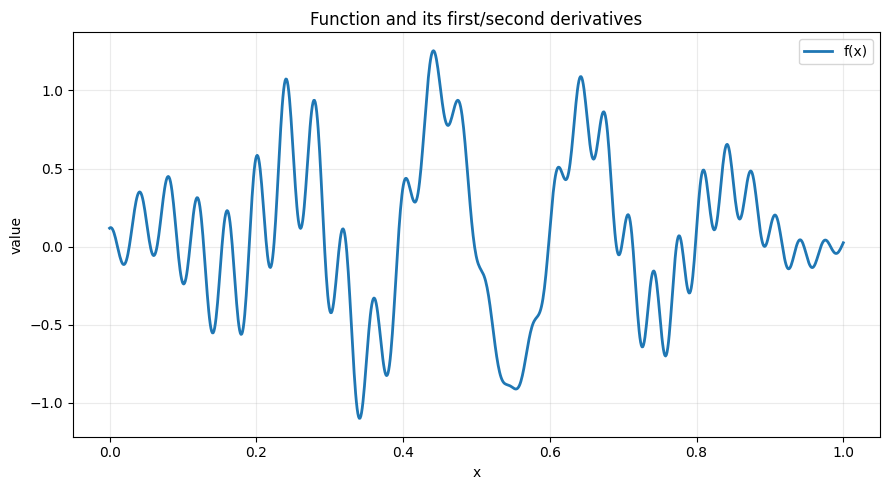

In [2]:
import torch
import matplotlib.pyplot as plt
import scipy  # (unused here; safe to remove)
from time import time

# Optional: better numerical stability
torch.set_default_dtype(torch.float64)

def test_function(x):
    term1 = torch.sin(10 * torch.pi * x) * torch.exp(-10 * (x - 0.5)**2)
    term2 = 0.5 * torch.cos(50 * torch.pi * x) * torch.exp(-20 * (x - 0.25)**2)
    term3 = 0.3 * torch.sin(60 * torch.pi * x) * torch.exp(-30 * (x - 0.75)**2)
    poly  = 0.2 * (x - 0.5)**3
    series = sum(0.1 / (2**n) * torch.sin((2 * n + 1) * torch.pi * x) for n in range(3))
    return term1 + term2 + term3 + poly + series

def noisy_test_function(x, noise_std=1e-7):
    y = test_function(x)
    noise = torch.randn_like(y) * noise_std
    return y + noise

# Domain
x = torch.linspace(0, 1, 1000, requires_grad=True)

# f(x)
y = test_function(x)

# f'(x)
dy_dx = torch.autograd.grad(
    outputs=y, inputs=x,
    grad_outputs=torch.ones_like(y),
    create_graph=True
)[0]

# f''(x)
d2y_dx2 = torch.autograd.grad(
    outputs=dy_dx, inputs=x,
    grad_outputs=torch.ones_like(dy_dx),
    create_graph=False
)[0]

# Plot all three
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x.detach().numpy(), y.detach().numpy(), label='f(x)', linewidth=2)
#ax.plot(x.detach().numpy(), dy_dx.detach().numpy(), label="f'(x)")
#ax.plot(x.detach().numpy(), d2y_dx2.detach().numpy(), label="f''(x)")
ax.set_xlabel('x')
ax.set_ylabel('value')
ax.set_title('Function and its first/second derivatives')
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


In [3]:
# 1D interpolation functions

In [4]:
import numpy as np
import torchtt as tntt
import torch as tn
import teneva as ten
p_coarse = 13
p_ext = 5
x0 = tn.linspace(0, 1, 2**p_coarse+1,requires_grad=True)[0:-1]
t1 = time()
y0 = test_function(x0)
# f'(x)
dy_dx = torch.autograd.grad(
    outputs=y0, inputs=x0,
    grad_outputs=torch.ones_like(y0),
    create_graph=True
)[0]

# f''(x)
d2y_dx2 = torch.autograd.grad(
    outputs=dy_dx, inputs=x0,
    grad_outputs=torch.ones_like(dy_dx),
    create_graph=False
)[0]
fc0 = tntt.TT(y0.detach(),[2]*(p_coarse),eps=1e-14)

c:\Users\siddhartha.morales\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchtt\_dmrg.py:19: UserWarning: 
C++ implementation not available. Using pure Python.

  warnings.warn("\x1B\nC++ implementation not available. Using pure Python.\n\033")
c:\Users\siddhartha.morales\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchtt\_amen.py:21: UserWarning: 
C++ implementation not available. Using pure Python.

  warnings.warn(
c:\Users\siddhartha.morales\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchtt\solvers.py:21: UserWarning: 
C++ implementation not available. Using pure Python.

  warnings.warn(
c:\Users\siddhartha.morales\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchtt\cpp.py:12: UserWarning: 
C++ implementation not available. Using pure Python.

  warnings.warn("\x1B\nC++ implementation not available. Using pure Python.\n\033")
c:\Users\siddhartha.morales\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchtt\__in

In [5]:
tntt.TT(d2y_dx2.detach(),[2]*(p_coarse),eps=1e-14)

TT with sizes and ranks:
N = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
R = [1, 2, 4, 8, 16, np.int64(17), np.int64(14), np.int64(11), np.int64(9), np.int64(8), np.int64(7), 4, 2, 1]

Device: cpu, dtype: torch.float64
#entries 2198 compression 0.268310546875

In [6]:
%cd ../..

from src.qtt_interpolation.utils import *

c:\Users\siddhartha.morales\OneDrive - Technology Innovation Institute\Documents\GitHub\QTT-polynomial-interpolation


C:\Users\siddhartha.morales\AppData\Roaming\Python\Python311\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [59]:
for n in range(2,8):

    p = 12
    I = tn.eye(n+1)
    j = 0
    O = tntt.kron( I_qtt(p),tntt.TT(I[j],[(1,n+1)]) )
    for i in range(-(n//2), n//2 +1 if n%2==0 else n//2+2):
        if i > 0:
            j += 1
            O += tntt.kron(P_qtt(2**p - i - 1,p),tntt.TT(I[j],[(1,n+1)]))
        elif i<0:
            j += 1
            O += tntt.kron(P_qtt(i ,p),tntt.TT(I[j],[(1,n+1)]))
    Or = O.round(1e-14)
    print(n, np.max(Or.R[:-2]),np.max(O.R[:-2]) )
    #print(np.max(zukron(O,O).round(1e-14).R[:-3]))
    #print(np.max(zukron3(Or,Or,Or).round(1e-13).R[:-4]))

2 4 5
3 5 7
4 5 9
5 5 11
6 6 13
7 7 15


In [72]:
p = 12
q = 8
for n in range(2,11):
    I = tn.eye(n+1)
    j = 0
    O = tntt.kron( I_qtt(p), tntt.TT(qtt_polynomial_cores(np.random.rand(n+1),q,dir='f')).to_ttm() )
    for i in range(-(n//2), n//2 +1 if n%2==0 else n//2+2):
        if i > 0:
            j += 1
            O += tntt.kron(P_qtt(2**p - i - 1,p),tntt.TT(qtt_polynomial_cores(np.random.rand(n+1),q,dir='f')).to_ttm() )
        elif i<0:
            j += 1
            O += tntt.kron(P_qtt(i ,p),tntt.TT(qtt_polynomial_cores(np.random.rand(n+1),q,dir='f')).to_ttm() )
    Or = O.round(1e-14)
    #print(Or)
    print(n, np.max(Or.R[:-2]),np.max(O.R) )
    print(np.max(zukron(Or,Or).round(1e-14).R))
    #print(np.max(zukron3(Or,Or,Or).round(1e-13).R[:-4]))

2 4 9
16
3 5 16
25
4 5 25
25
5 6 36
36
6 7 49
49
7 8 64
64
8 9 81
80
9 10 100
99
10 11 121
115


In [76]:
print(np.max(zukron(Or,Or).round(1e-15).R))

119


In [ ]:
for n in range(2,10):

    p = 20
    I = tn.eye(n+1)
    j = 0
    O =  I_qtt(p)
    for i in range(-(n//2), n//2 +1 if n%2==0 else n//2+2):
        if i > 0:
            j += 1
            O += P_qtt(2**p - i - 1,p)
        elif i<0:
            j += 1
            O += P_qtt(i ,p)
    Or = O.round(1e-15)
    print(n, np.max(Or.R),np.max(O.R) )
    #print(np.max(zukron(O,O).round(1e-14).R))
    #print(np.max(zukron3(Or,Or,Or).round(1e-13).R))

2 4 5
3 4 7
4 4 9
5 4 11
6 4 13
7 5 15
8 5 17
9 5 19


In [31]:
Or

TT-matrix with sizes and ranks:
M = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
N = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
R = [1, 2, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 3, 1]
Device: cpu, dtype: torch.float64
#entries 1128 compression 1.025910023599863e-09

In [43]:
n = 7
p = 12
I = tn.eye(n+1)
j = 0
O = tntt.kron( I_qtt(p),tntt.TT(I[j],[(1,n+1)]) )
for i in range(-(n//2), n//2 +1 if n%2==0 else n//2+2):
    if i > 0:
        j += 1
        O += tntt.kron(P_qtt(2**p - i - 1,p),tntt.TT(I[j],[(1,n+1)]))
    elif i<0:
        j += 1
        O += tntt.kron(P_qtt(i ,p),tntt.TT(I[j],[(1,n+1)]))
Or = O.round(1e-14)
Or

TT-matrix with sizes and ranks:
M = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1]
N = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 8]
R = [1, 2, 3, 4, 4, 4, 4, 4, 4, 4, 5, 7, 8, 1]
Device: cpu, dtype: torch.float64
#entries 972 compression 7.241964340209961e-06

In [46]:
np.max(zukron(Or,Or).round(1e-14).R[:-3])

np.int64(56)